# Chart creation

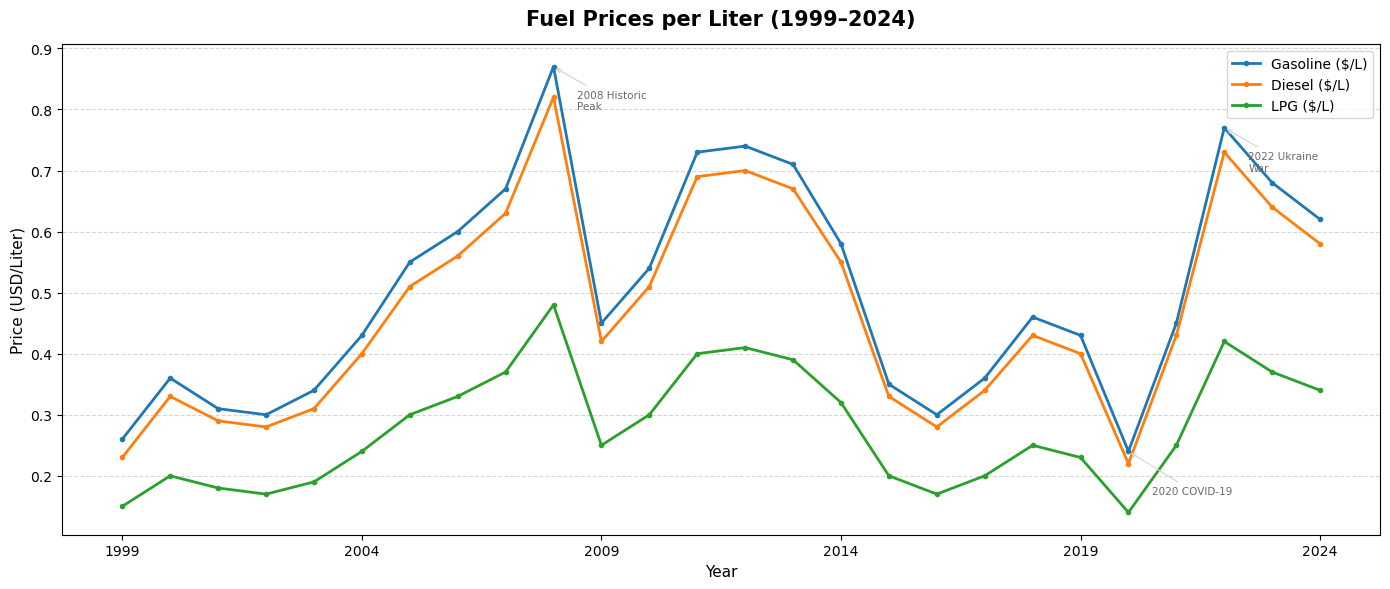

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load Data ---
df = pd.read_csv("fuel_prices_1975_2024.csv")

df = df[df["year"] >= 1999]  # <-- filter here

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df["year"], df["gasoline_usd_per_liter"], label="Gasoline ($/L)", linewidth=2, marker="o", markersize=3)
ax.plot(df["year"], df["diesel_usd_per_liter"],   label="Diesel ($/L)",   linewidth=2, marker="o", markersize=3)
ax.plot(df["year"], df["lpg_usd_per_liter"],      label="LPG ($/L)",      linewidth=2, marker="o", markersize=3)

# Annotate key events (only post-1999 ones)
events = {
    2008: "2008 Historic\nPeak",
    2020: "2020 COVID-19",
    2022: "2022 Ukraine\nWar",
}

'''
# Annotate key events
events = {
    1979: "Iranian\nRevolution",
    1986: "OPEC\nPrice War",
    2008: "Historic\nPeak",
    2020: "COVID-19",
    2022: "Ukraine\nWar",
}
'''
for year, label in events.items():
    x = year
    y = df.loc[df["year"] == year, "gasoline_usd_per_liter"].values[0]
    ax.annotate(label, xy=(year, y), xytext=(year + 0.5, y - 0.07),
                fontsize=7.5, color="dimgray",
                arrowprops=dict(arrowstyle="->", color="lightgray", lw=0.8))

ax.set_title("Fuel Prices per Liter (1999–2024)", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Price (USD/Liter)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_xticks(df["year"][::5])
plt.tight_layout()
plt.savefig("fuel_prices_line_chart.png", dpi=150)
plt.show()

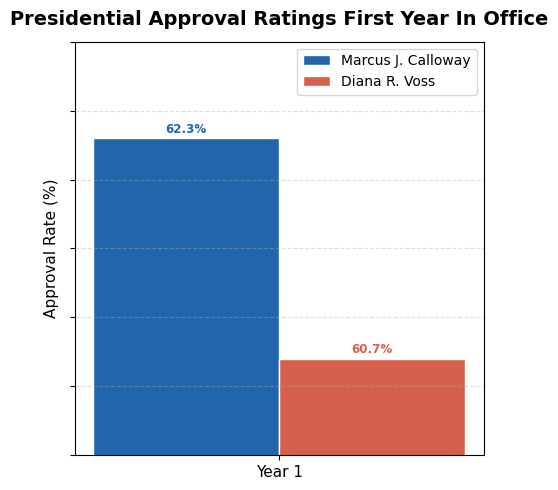

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Data ---
'''
data = {
    "year_in_office": ["Year 1", "Year 2", "Year 3", "Year 4"],
    "calloway_approval": [62.3, 54.1, 49.8, 51.4],
    "voss_approval":     [58.7, 55.3, 52.1, 48.6],
}
'''

data = {
    "year_in_office": ["Year 1"],
    "calloway_approval": [62.3],
    "voss_approval":     [60.7]
}

df = pd.DataFrame(data)

# --- Plot Settings ---
Y_MIN = 60   # <-- Adjust to exaggerate the visual difference
Y_MAX = 63

x = np.arange(len(df["year_in_office"]))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 5))

bars1 = ax.bar(x - width/2, df["calloway_approval"], width, label="Marcus J. Calloway",
               color="#2166ac", edgecolor="white")
bars2 = ax.bar(x + width/2, df["voss_approval"],     width, label="Diana R. Voss",
               color="#d6604d", edgecolor="white")

# Annotate bars
for bar in bars1:
    ax.annotate(f"{bar.get_height()}%",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=8.5, color="#2166ac", fontweight="bold")

for bar in bars2:
    ax.annotate(f"{bar.get_height()}%",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=8.5, color="#d6604d", fontweight="bold")

ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xticks(x)
ax.set_xticklabels(df["year_in_office"], fontsize=11)
ax.set_ylabel("Approval Rate (%)", fontsize=11)
ax.set_title("Presidential Approval Ratings First Year In Office", fontsize=14, fontweight="bold", pad=12)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
ax.set_yticklabels([]) # removes the y axis labels
plt.savefig("approval_ratings.png", dpi=150, bbox_inches="tight")
plt.show()

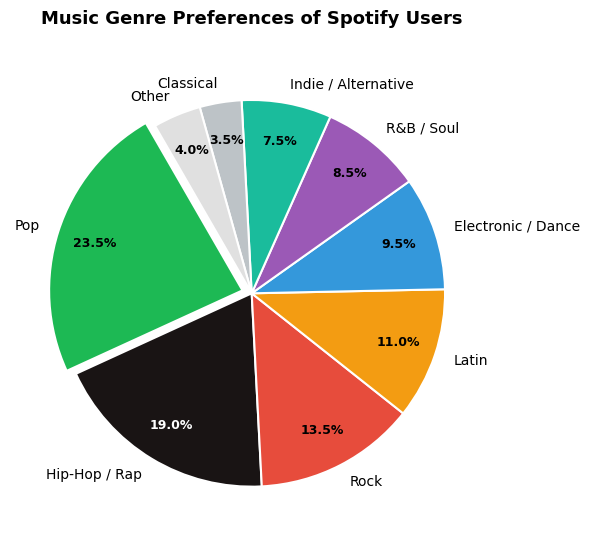

In [1]:
import matplotlib.pyplot as plt

# --- Data: Spotify Genre Preferences (fictitious) ---
labels  = ["Pop", "Hip-Hop / Rap", "Rock", "Latin", "Electronic / Dance",
           "R&B / Soul", "Indie / Alternative", "Classical", "Other"]
sizes   = [23.5, 19.0, 13.5, 11.0, 9.5, 8.5, 7.5, 3.5, 4.0]
colors  = ["#1DB954", "#191414", "#e74c3c", "#f39c12", "#3498db",
           "#9b59b6", "#1abc9c", "#bdc3c7", "#e0e0e0"]
explode = (0.05, 0, 0, 0, 0, 0, 0, 0, 0)  # highlight Pop as the dominant genre

fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct="%1.1f%%",
    startangle=120,
    pctdistance=0.80,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)

for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight("bold")

autotexts[1].set_color("white")
ax.set_title("Music Genre Preferences of Spotify Users",
             fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("spotify_genre_pie_chart.png", dpi=150, bbox_inches="tight")
plt.show()